# 3개년 통합 연고관광 사전 층화 군집분석

## 분석 질문

2023~2025년 국민여행조사 통합·조화본에서 관광·휴양 활동을 포함한
가족·친지·친구 방문(CASE 2)을 당일여행과 숙박여행으로 먼저 나누면,
각 층 안에서 준비·활동·동반·숙박시설·이동·소비가 함께 구별되는
안정적인 하위 행동유형이 나타나는가?

`260719_연고관광_사전층화_클러스터링_2025년.ipynb`의 방법론(다섯 모형 ×
객관적 엘보우 × 자체/공통 Gower 실루엣 × 시드 안정성 × Pareto 선택)을
3개년 통합 표본으로 재현하되, 변수 확장의 영향을 단계적으로 보기 위해
두 단계로 나눈다.

1. **1단계(baseline)**: 기존 F2 행동특성(약 30개) + 인구통계
2. **2단계(full)**: 1단계 + 소비·준비 세부항목까지 포함한 확장 변수셋

각 단계는 같은 재사용 파이프라인 함수로 실행하며, 결과를 각각 저장해
비교한다. 두 단계 모두 최종 결과에 `군집` 열을 더한 라벨링 데이터를
별도로 저장한다.

> 분석 단위는 CASE 2로 필터링한 응답자·조사회차(`YEAR + ID`)다.
> `WT_DOM`은 군집 생성에는 쓰지 않고 층·군집별 가중 사례 구성과
> 프로파일에만 사용한다. 결과는 연관성이며 정책의 인과효과가 아니다.

In [ ]:
from itertools import combinations
from pathlib import Path
import re
import sys
import warnings

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").is_dir():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("src 폴더가 있는 프로젝트 루트를 찾지 못했습니다.")
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import gower
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn_extra.cluster import KMedoids

from src.path import (
    NATIONAL_TRAVEL_SURVEY_PREPROCESSED_DATA_DIR,
    create_output_directories,
)
from src.visualization import COLORS, PALETTE, apply_plot_style

warnings.filterwarnings("ignore", category=FutureWarning)
apply_plot_style()
NOTEBOOK_NAME = "260720_연고관광_사전층화_클러스터링_3개년.ipynb"
FIGURES_DIR, TABLES_DIR = create_output_directories(NOTEBOOK_NAME)
MODELS_DIR = FIGURES_DIR.parent / "models"

RANDOM_STATE = 20260720
SEEDS = [20260720, 17, 43, 101, 2025]
K_VALUES = range(1, 9)
SILHOUETTE_SAMPLE = 1200
MIN_CLUSTER_SHARE = 0.05
MIN_STABILITY_ARI = 0.5
MODEL_NAMES = [
    "유클리드 K-means",
    "유클리드 K-medoids",
    "Gower K-medoids",
    "임베딩 K-means",
    "임베딩 K-medoids",
]

PREPROCESSED_PATH = (
    NATIONAL_TRAVEL_SURVEY_PREPROCESSED_DATA_DIR
    / "national_travel_survey_2023_2025_preprocessed.csv"
)
CODEBOOK_PATH = (
    NATIONAL_TRAVEL_SURVEY_PREPROCESSED_DATA_DIR
    / "national_travel_survey_2023_2025_preprocessed_codebook.csv"
)
print(f"원자료: {PREPROCESSED_PATH.name}")
print(f"K 후보: {min(K_VALUES)}~{max(K_VALUES)}")
print(f"반복 시드: {SEEDS}")

원자료: national_travel_survey_2023_2025_preprocessed.csv
K 후보: 1~8
반복 시드: [20260720, 17, 43, 101, 2025]


## 1. 데이터 로드와 타입 캐스팅

통합 코드북의 `column_type`에 맞춰 `scale`은 수치형으로, `nominal`은
비결측값이 모두 정수로 해석되면 nullable `Int64`로, 아니면 문자열로
유지한다. 값 라벨은 적용하지 않고 공식 숫자 코드를 그대로 쓴다.

In [2]:
def cast_by_column_type(
    frame: pd.DataFrame, codebook: pd.DataFrame
) -> pd.DataFrame:
    '''통합 코드북의 column_type에 맞춰 원자료 열의 dtype을 지정한다.

    Args:
        frame: 캐스팅할 원자료.
        codebook: `column_name`, `column_type`을 포함한 통합 변수 사전.

    Returns:
        타입을 지정한 자료 사본.
    '''
    result = frame.copy()
    type_map = codebook.set_index("column_name")["column_type"]
    for column in result.columns:
        column_type = type_map.get(column)
        if column_type == "scale":
            result[column] = pd.to_numeric(result[column], errors="coerce")
        elif column_type == "nominal":
            non_null = result[column].dropna()
            numeric = pd.to_numeric(non_null, errors="coerce")
            is_integer_like = (
                len(non_null) > 0
                and numeric.notna().all()
                and numeric.eq(numeric.round()).all()
            )
            if is_integer_like:
                result[column] = pd.to_numeric(
                    result[column], errors="coerce"
                ).astype("Int64")
            else:
                result[column] = result[column].astype("object")
    return result


codebook = pd.read_csv(CODEBOOK_PATH, encoding="utf-8-sig")
raw_data = pd.read_csv(PREPROCESSED_PATH, low_memory=False)
raw_data = cast_by_column_type(raw_data, codebook)

print(f"원자료 shape: {raw_data.shape}")
print("column_type 분포:")
display(codebook["column_type"].value_counts())
missing_share = (
    raw_data.isna().mean().sort_values(ascending=False).head(15)
)
print("결측 비율 상위 15개 열:")
display(missing_share.rename("결측 비율").to_frame())

원자료 shape: (156050, 591)
column_type 분포:


column_type
nominal    318
scale      273
Name: count, dtype: int64

결측 비율 상위 15개 열:


,결측 비율
A8SA_1,1.0
A8SA_2,1.0
D_TRA_17_Q6,1.0
A8SB_1,1.0
A8SB_2,1.0
TA5A_11,1.0
D_TRA_17_Q6_Ar,1.0
D_TRA_17_SPOT,1.0
D_TRA_17_EDAY,1.0
D_TRA_17_EMONTH,1.0


## 2. 정제와 분석 단위 확정

구조적 결측(`-1` 코드)을 NaN으로 바꾸고, 여행 전체 일자로 대체된
방문지별 날짜열·자유응답 존재 플래그·비용 인원수(P-접두) 열 등 구조적으로
불필요한 열을 제거한다. 그 뒤 `D_TRA_CASE == 2`로 표본을 필터링하고
층(당일/숙박)을 만든다.

In [3]:
structural_missing_columns = codebook.loc[
    codebook["structural_missing_code"].notna(), "column_name"
].tolist()
for column in structural_missing_columns:
    code_text = str(
        codebook.loc[
            codebook["column_name"].eq(column), "structural_missing_code"
        ].iloc[0]
    )
    missing_code = int(code_text.split("=")[0])
    raw_data[column] = raw_data[column].replace(missing_code, pd.NA)
print(f"구조적 결측(-1) 처리 열 수: {len(structural_missing_columns)}")

empty_columns_before = [
    column for column in raw_data.columns if raw_data[column].notna().sum() == 0
]
raw_data = raw_data.drop(columns=empty_columns_before)
print(f"필터 전 전역 빈 컬럼 제거: {len(empty_columns_before)}개")

structural_exclusion_pattern = re.compile(
    r"^(D1_\d+|PD1_\d+|ND_TOTAL|D_TRA_NUM|PA\d.*|TA\d.*"
    r"|MA6B_2\d\d|MA6B_3\d\d"
    r"|D_TRA_\d+_(SYEAR|SMONTH|SDAY|EYEAR|EMONTH|EDAY))$"
)
structural_excluded = [
    column for column in raw_data.columns
    if structural_exclusion_pattern.match(column)
]
raw_data = raw_data.drop(columns=structural_excluded)
print(f"구조적 제외 열: {len(structural_excluded)}개")

raw_data["D_TRA_CASE"] = pd.to_numeric(raw_data["D_TRA_CASE"], errors="coerce")
analysis_data = raw_data.loc[raw_data["D_TRA_CASE"].eq(2)].copy()

empty_columns_after = [
    column for column in analysis_data.columns
    if analysis_data[column].notna().sum() == 0
]
analysis_data = analysis_data.drop(columns=empty_columns_after)
print(f"필터 후 전역 빈 컬럼 제거: {len(empty_columns_after)}개")

analysis_data["nights"] = pd.to_numeric(
    analysis_data["D_TRA_S_Day"], errors="coerce"
).clip(lower=0)
analysis_data["overnight_trip"] = analysis_data["nights"].gt(0).astype(int)
analysis_data["층"] = np.where(
    analysis_data["overnight_trip"].eq(1), "숙박여행", "당일여행"
)

sample_flow = (
    analysis_data.groupby(["YEAR", "층"], sort=False)
    .agg(비가중_N=("ID", "size"), 가중_여행_사례_수=("WT_DOM", "sum"))
    .reset_index()
)
sample_flow.loc[len(sample_flow)] = [
    "전체", "전체", len(analysis_data), analysis_data["WT_DOM"].sum()
]
sample_flow.to_csv(
    TABLES_DIR / "stratified_cluster_sample_flow.csv",
    index=False,
    encoding="utf-8-sig",
)
display(sample_flow.round(2))

assert analysis_data["ID"].is_unique
assert analysis_data["WT_DOM"].notna().all()
assert analysis_data["WT_DOM"].gt(0).all()
assert analysis_data["층"].isin(["당일여행", "숙박여행"]).all()

구조적 결측(-1) 처리 열 수: 15
필터 전 전역 빈 컬럼 제거: 37개
구조적 제외 열: 187개
필터 후 전역 빈 컬럼 제거: 23개


,YEAR,층,비가중_N,가중_여행_사례_수
0,2023,당일여행,2049,2.045673e+07
1,2023,숙박여행,2383,2.433257e+07
2,2024,숙박여행,2383,2.386344e+07
3,2024,당일여행,2156,2.181443e+07
4,2025,숙박여행,2314,2.212268e+07
5,2025,당일여행,1505,1.395201e+07
6,전체,전체,12790,1.265419e+08


## 3. 공통 파생 변수 생성

두 단계 모두에서 쓰는 F2 행동특성과 인구통계, 그리고 2단계 확장에서만
쓰는 소비·준비 세부항목을 함께 만들어 둔다. `D_TRA_B7_1`은 3개년
통합본에서 지역간·지역내를 이미 합친 변수이므로 자가용 계열(1=자가용,
8=차량대여/렌트)과 대중교통 계열(2=철도, 3=항공기, 4=선박, 5=지하철,
6/7=버스)만 이분해 파생한다.

In [4]:
reservation_columns = [
    "A2_1", "A2_2", "A2_3", "A2_4", "A2_5", "A2_6", "A2_7",
    "A2_10", "A2_11",
]
information_columns = ["A5_1", "A5_2", "A5_3"]
activity_groups = {
    "activity_nature": [1],
    "activity_food": [2],
    "activity_culture": [4, 9, 13, 15, 16],
    "activity_experience": [5, 12, 20],
    "activity_leisure": [3, 10],
    "activity_wellness": [6, 7],
    "activity_shopping": [8, 14, 17],
    "activity_event": [11],
}
activity_group_columns = list(activity_groups)

reservation_values = analysis_data[reservation_columns].apply(
    pd.to_numeric, errors="coerce"
)
information_values = analysis_data[information_columns].apply(
    pd.to_numeric, errors="coerce"
)

analysis_data["package_used"] = analysis_data["A1"].isin([1, 2]).astype(int)
analysis_data["reservation_any"] = reservation_values.eq(1).any(axis=1).astype(int)
analysis_data["reservation_count"] = reservation_values.eq(1).sum(axis=1)
analysis_data["information_none"] = information_values.eq(8).any(axis=1).astype(int)
analysis_data["information_online"] = information_values.eq(1).any(axis=1).astype(int)
analysis_data["information_people"] = information_values.eq(5).any(axis=1).astype(int)

for name, codes in activity_groups.items():
    item_columns = [f"A4_{code}" for code in codes]
    analysis_data[name] = (
        analysis_data[item_columns].eq(1).any(axis=1).astype(int)
    )
analysis_data["activity_group_count"] = analysis_data[
    activity_group_columns
].sum(axis=1)

analysis_data["party_size"] = pd.to_numeric(analysis_data["A6"], errors="coerce")
analysis_data["party_group"] = pd.cut(
    analysis_data["party_size"],
    bins=[0, 1, 2, 4, np.inf],
    labels=["1인", "2인", "소규모(3~4인)", "대규모(5인 이상)"],
).astype("object")
child_count = pd.to_numeric(analysis_data["A6A"], errors="coerce").fillna(0)
analysis_data["with_child"] = child_count.gt(0).astype(int)

spot_columns = [
    column for column in (f"D_TRA_{spot}_SPOT" for spot in range(1, 18))
    if column in analysis_data.columns
]
lodging_columns = [
    column for column in (f"D_TRA_{spot}_Q6" for spot in range(1, 18))
    if column in analysis_data.columns
]
selected_spots = analysis_data[spot_columns].apply(pd.to_numeric, errors="coerce")
selected_lodging = analysis_data[lodging_columns].apply(
    pd.to_numeric, errors="coerce"
)
analysis_data["visit_region_count"] = selected_spots.nunique(axis=1)
analysis_data["multi_region"] = analysis_data["visit_region_count"].gt(1).astype(int)
analysis_data["family_home_lodging"] = selected_lodging.eq(12).any(axis=1).astype(int)
analysis_data["commercial_lodging"] = (
    selected_lodging.isin(range(1, 12)).any(axis=1).astype(int)
)

analysis_data["primary_transport"] = (
    pd.to_numeric(analysis_data["D_TRA_B7_1"], errors="coerce")
    .astype("Int64").astype(str)
)
transport_code = pd.to_numeric(analysis_data["D_TRA_B7_1"], errors="coerce")
analysis_data["car_dependence"] = transport_code.isin([1, 8]).astype(int)
analysis_data["public_transport"] = transport_code.isin(
    [2, 3, 4, 5, 6, 7]
).astype(int)

analysis_data["trip_days"] = analysis_data["nights"] + 1
analysis_data["spend_per_person"] = pd.to_numeric(
    analysis_data["D_TRA_ONE_COST"], errors="coerce"
)
analysis_data["spend_per_person_day"] = (
    analysis_data["spend_per_person"]
    / analysis_data["trip_days"].replace(0, np.nan)
)
spend_cap = analysis_data["spend_per_person_day"].quantile(0.99)
analysis_data["log_spend_per_person_day"] = np.log1p(
    analysis_data["spend_per_person_day"].clip(upper=spend_cap)
)
analysis_data["destination_spend"] = pd.to_numeric(
    analysis_data["A8"], errors="coerce"
)
spend_share_map = {
    "share_lodging": ["A8C"],
    "share_food": ["A8D", "A8E"],
    "share_transport": ["A8F"],
    "share_activity": ["A8G"],
    "share_shopping": ["A8H", "A8I"],
}
for name, columns in spend_share_map.items():
    numerator = analysis_data[columns].apply(
        pd.to_numeric, errors="coerce"
    ).fillna(0).sum(axis=1)
    analysis_data[name] = (
        numerator / analysis_data["destination_spend"].replace(0, np.nan)
    ).clip(0, 1).fillna(0)
analysis_data["activity_spend"] = analysis_data["share_activity"].gt(0).astype(int)
analysis_data["local_food_shopping_spend"] = (
    analysis_data["share_food"] + analysis_data["share_shopping"]
).gt(0).astype(int)

print("공통 F2 파생 변수 생성 완료")

공통 F2 파생 변수 생성 완료


## 4. 2단계 전용 소비·준비 세부항목

사전지출(`A7_TOTAL`/`NA7_*`), 목적지 지출 총액·1인당 세부항목
(`A8*`/`NA8*`), 세부 지출 비중(`A8SA~A8SF`)과 예약 시점·방문지 선택
이유·정보원 세부(`A1A`, `A3_RANKW_*`, `A5A_*`)는 2단계(full)에서만
군집 입력에 사용한다. 여기서는 수치형 캐스팅만 미리 해 둔다.

In [5]:
na7_columns = [f"NA7_{number}" for number in range(1, 11)] + ["NA7_TOTAL"]
a8_total_columns = [f"A8{letter}" for letter in "ABCDEFGHIJ"] + ["A8"]
na8_columns = (
    [f"NA8A_{i}" for i in range(1, 4)] + ["NA8B"]
    + [f"NA8C_{i}" for i in range(1, 15)]
    + [f"NA8D_{i}" for i in range(1, 4)]
    + [f"NA8E_{i}" for i in range(1, 5)]
    + [f"NA8F_{i}" for i in [1, 2, 3, 4, 6]]
    + [f"NA8FA_{i}" for i in range(1, 5)]
    + [f"NA8G_{i}" for i in range(1, 7)]
    + [f"NA8H_{i}" for i in range(1, 6)]
    + [f"NA8I_{i}" for i in range(1, 4)]
    + ["NA8J_1", "NA8"]
)
a8_share_columns = (
    [f"A8SA_{i}" for i in range(1, 3)]
    + [f"A8SB_{i}" for i in range(1, 3)]
    + [f"A8SC_{i}" for i in range(1, 8)]
    + [f"A8SD_{i}" for i in range(1, 7)]
    + [f"A8SE_{i}" for i in range(1, 4)]
    + [f"A8SF_{i}" for i in range(1, 5)]
)
spend_detail_columns_requested = (
    ["A7_TOTAL"] + na7_columns + a8_total_columns + na8_columns + a8_share_columns
)
spend_detail_columns = [
    column for column in spend_detail_columns_requested
    if column in analysis_data.columns
]
dropped_spend_columns = sorted(
    set(spend_detail_columns_requested) - set(spend_detail_columns)
)
if dropped_spend_columns:
    print(f"CASE 2 표본에서 전부 결측이라 제외한 소비 세부 변수: {dropped_spend_columns}")
for column in spend_detail_columns:
    analysis_data[column] = pd.to_numeric(analysis_data[column], errors="coerce")

reservation_timing_columns = ["A1A"]
destination_reason_columns_requested = [f"A3_RANKW_{i}" for i in range(1, 16)]
destination_reason_columns = [
    column for column in destination_reason_columns_requested
    if column in analysis_data.columns
]
information_detail_categorical = ["A5A_1", "A5A_2", "A5A_3"]
information_detail_rankw_requested = [
    f"A5A_RANKW_{i}" for i in [1, 2, 3, 4, 6, 7, 8, 9]
]
information_detail_rankw = [
    column for column in information_detail_rankw_requested
    if column in analysis_data.columns
]
for column in destination_reason_columns + information_detail_rankw:
    analysis_data[column] = pd.to_numeric(analysis_data[column], errors="coerce")
analysis_data["A1A"] = pd.to_numeric(
    analysis_data["A1A"], errors="coerce"
).astype("Int64").astype(str)
for column in information_detail_categorical:
    analysis_data[column] = pd.to_numeric(
        analysis_data[column], errors="coerce"
    ).astype("Int64").astype(str)

preparation_detail_columns = (
    reservation_timing_columns + destination_reason_columns
    + information_detail_categorical + information_detail_rankw
)
print(f"2단계 전용 소비 세부 변수: {len(spend_detail_columns)}개")
print(f"2단계 전용 준비·정보 세부 변수: {len(preparation_detail_columns)}개")

CASE 2 표본에서 전부 결측이라 제외한 소비 세부 변수: ['A8SA_1', 'A8SA_2', 'A8SB_1', 'A8SB_2']
2단계 전용 소비 세부 변수: 93개
2단계 전용 준비·정보 세부 변수: 27개


## 5. 두 단계의 feature_domain 정의

1단계(baseline)는 기존 F2 여섯 영역에 인구통계 영역을 더한다.
2단계(full)는 baseline의 일곱 영역에 소비 세부·준비 세부 두 영역을
추가한다. Gower 거리는 영역별 총가중치를 같게 맞추므로 영역 수가
늘어난 2단계에서도 인구통계·활동 같은 기존 영역의 상대적 비중이
유지된다.

In [6]:
demographic_nominal = [
    "BSEX", "BAGE", "BJOB", "BINC1", "BINC2", "BEDU", "BMAR",
    "BFAM", "BARA", "BMON", "DQ7", "DQ8",
]
demographic_scale = ["DQ3A", "DQ5AC"]
for column in demographic_nominal:
    analysis_data[column] = (
        pd.to_numeric(analysis_data[column], errors="coerce")
        .astype("Int64").astype(str)
    )
for column in demographic_scale:
    analysis_data[column] = pd.to_numeric(analysis_data[column], errors="coerce")

FEATURE_DOMAINS_BASELINE = {
    "여행 준비": [
        "package_used", "reservation_any", "reservation_count",
        "information_none", "information_online", "information_people",
    ],
    "관광활동": activity_group_columns + ["activity_group_count"],
    "동반 형태": ["party_size", "party_group", "with_child"],
    "체류·숙박": ["family_home_lodging", "commercial_lodging"],
    "이동·방문": [
        "primary_transport", "car_dependence", "public_transport",
        "visit_region_count", "multi_region",
    ],
    "소비": [
        "log_spend_per_person_day", "share_lodging", "share_food",
        "share_transport", "share_activity", "share_shopping",
        "activity_spend", "local_food_shopping_spend",
    ],
    "인구통계": demographic_nominal + demographic_scale,
}
CATEGORICAL_FEATURES_BASELINE = set(demographic_nominal) | {
    "party_group", "primary_transport",
}

FEATURE_DOMAINS_FULL = dict(FEATURE_DOMAINS_BASELINE)
FEATURE_DOMAINS_FULL["소비 상세"] = spend_detail_columns
FEATURE_DOMAINS_FULL["준비·정보 상세"] = preparation_detail_columns
CATEGORICAL_FEATURES_FULL = CATEGORICAL_FEATURES_BASELINE | {
    "A1A", "A5A_1", "A5A_2", "A5A_3",
}

for phase_name, feature_domain in [
    ("baseline", FEATURE_DOMAINS_BASELINE), ("full", FEATURE_DOMAINS_FULL)
]:
    definition = pd.DataFrame([
        {"단계": phase_name, "영역": domain, "변수": feature}
        for domain, features in feature_domain.items()
        for feature in features
    ])
    definition.to_csv(
        TABLES_DIR / f"{phase_name}_stratified_cluster_feature_definitions.csv",
        index=False,
        encoding="utf-8-sig",
    )
print("baseline 변수 수:", sum(len(v) for v in FEATURE_DOMAINS_BASELINE.values()))
print("full 변수 수:", sum(len(v) for v in FEATURE_DOMAINS_FULL.values()))

baseline 변수 수: 47
full 변수 수: 167


## 6. 캐싱과 전처리 헬퍼

`load_or_compute`는 캐시 파일이 있으면 로드하고 없으면 계산 후
저장한다. 유클리드·Gower 전처리와 오토인코더 임베딩은 층·단계별로
한 번만 계산한다.

In [7]:
def load_or_compute(path, compute_fn):
    '''캐시 파일이 있으면 로드하고 없으면 계산해 저장한다.

    Args:
        path: 캐시 파일 경로.
        compute_fn: 인자 없이 결과를 반환하는 계산 함수.

    Returns:
        캐시되거나 새로 계산한 결과.
    '''
    if path.is_file():
        return joblib.load(path)
    result = compute_fn()
    path.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(result, path)
    return result


def build_euclidean_matrix(frame, features, categorical_features, feature_domain):
    '''유클리드 군집과 오토인코더용 도메인 균형 전처리 행렬을 만든다.

    Gower 거리처럼 원본 변수 하나당 `1/도메인 내 변수 수` 가중치를 주지
    않으면, 인구통계처럼 원-핫 컬럼이 많은 도메인이 체류·숙박처럼
    변수가 적은 도메인을 압도한다. 제곱 유클리드 거리에 그 가중치가
    그대로 반영되도록 각 컬럼에 가중치의 제곱근을 곱한다.

    Args:
        frame: 한 층의 여행 자료.
        features: 사용할 변수명.
        categorical_features: 범주형으로 취급할 변수명 집합.
        feature_domain: 영역명과 그 안의 변수 목록.

    Returns:
        도메인 균형 가중이 적용된 전처리 행렬(float32 배열).
    '''
    categorical = [f for f in features if f in categorical_features]
    numeric = [f for f in features if f not in categorical]
    preprocessor = ColumnTransformer(
        [
            (
                "numeric",
                Pipeline([
                    ("impute", SimpleImputer(strategy="median")),
                    ("scale", RobustScaler()),
                ]),
                numeric,
            ),
            (
                "categorical",
                Pipeline([
                    ("impute", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore", sparse_output=False
                        ),
                    ),
                ]),
                categorical,
            ),
        ],
        verbose_feature_names_out=False,
    )
    matrix = preprocessor.fit_transform(frame[features]).astype(np.float32)

    domain_weight = {}
    for feature in features:
        domain = next(
            name for name, items in feature_domain.items() if feature in items
        )
        domain_count = sum(item in features for item in feature_domain[domain])
        domain_weight[feature] = 1.0 / domain_count

    column_weights = [domain_weight[feature] for feature in numeric]
    if categorical:
        onehot = preprocessor.named_transformers_["categorical"].named_steps["onehot"]
        for feature, categories in zip(categorical, onehot.categories_):
            column_weights.extend([domain_weight[feature]] * len(categories))
    column_scale = np.sqrt(np.asarray(column_weights, dtype=np.float32))
    return (matrix * column_scale).astype(np.float32)


def build_gower_matrix(frame, features, categorical_features, feature_domain):
    '''영역 균형 가중 Gower 거리행렬을 만든다.

    Args:
        frame: 한 층의 여행 자료.
        features: 사용할 변수명.
        categorical_features: 범주형으로 취급할 변수명 집합.
        feature_domain: 영역명과 그 안의 변수 목록.

    Returns:
        Gower 거리행렬(float32 배열).
    '''
    prepared = frame[features].copy()
    categorical_mask = []
    weights = []
    for feature in features:
        is_categorical = feature in categorical_features
        categorical_mask.append(is_categorical)
        if is_categorical:
            mode = prepared[feature].mode(dropna=True)
            fill_value = mode.iloc[0] if not mode.empty else "정보없음"
            prepared[feature] = prepared[feature].fillna(fill_value).astype(str)
        else:
            prepared[feature] = pd.to_numeric(prepared[feature], errors="coerce")
            prepared[feature] = prepared[feature].fillna(prepared[feature].median())
        domain = next(
            name for name, items in feature_domain.items() if feature in items
        )
        domain_count = sum(item in features for item in feature_domain[domain])
        weights.append(1.0 / domain_count)
    distance = gower.gower_matrix(
        prepared,
        weight=np.asarray(weights, dtype=float),
        cat_features=np.asarray(categorical_mask),
    ).astype(np.float32)
    np.fill_diagonal(distance, 0)
    return distance


def autoencoder_embedding(matrix, seed):
    '''64→16→64 오토인코더의 병목 좌표를 만든다.

    Args:
        matrix: 원-핫·스케일링된 입력행렬.
        seed: 난수 시드.

    Returns:
        16차원 병목 임베딩과 마지막 내부 검증 R².
    '''
    model = MLPRegressor(
        hidden_layer_sizes=(64, 16, 64),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        batch_size=64,
        learning_rate_init=1e-3,
        max_iter=250,
        early_stopping=True,
        validation_fraction=0.2,
        n_iter_no_change=15,
        random_state=seed,
    )
    model.fit(matrix, matrix)
    hidden = matrix
    for layer in range(2):
        hidden = np.maximum(0, hidden @ model.coefs_[layer] + model.intercepts_[layer])
    return hidden.astype(np.float32), float(model.validation_scores_[-1])


def pairwise_ari(label_list):
    '''여러 군집 라벨 사이의 평균 ARI를 계산한다.

    Args:
        label_list: 반복별 군집 라벨 목록.

    Returns:
        모든 반복 쌍의 평균 ARI.
    '''
    return float(np.mean([
        adjusted_rand_score(left, right)
        for left, right in combinations(label_list, 2)
    ]))


def silhouette_indices(size, seed):
    '''실루엣 곡선용 고정 표본 인덱스를 만든다.

    Args:
        size: 층의 관측 수.
        seed: 표본 추출 시드.

    Returns:
        정렬된 표본 인덱스.
    '''
    sample_size = min(SILHOUETTE_SAMPLE, size)
    rng = np.random.default_rng(seed)
    return np.sort(rng.choice(size, sample_size, replace=False))


def normalize_objective(group):
    '''한 시드의 목적함수 곡선을 1~0 범위로 정규화한다.

    Args:
        group: 한 층·모형·시드의 K별 결과.

    Returns:
        원래 인덱스를 유지한 정규화 목적함수.
    '''
    ordered = group.sort_values("K")
    first = ordered.loc[ordered["K"].eq(min(K_VALUES)), "목적함수"].iloc[0]
    last = ordered.loc[ordered["K"].eq(max(K_VALUES)), "목적함수"].iloc[0]
    denominator = first - last
    if np.isclose(denominator, 0):
        normalized = pd.Series(0.0, index=ordered.index)
    else:
        normalized = (ordered["목적함수"] - last) / denominator
    return normalized.reindex(group.index)


def weighted_mean(values, weights):
    '''결측을 쌍별 제외해 가중 평균을 계산한다.

    Args:
        values: 평균을 계산할 수치.
        weights: 같은 인덱스의 양수 가중치.

    Returns:
        유효 관측치의 가중 평균.
    '''
    numeric = pd.to_numeric(values, errors="coerce")
    valid = numeric.notna() & weights.notna() & weights.gt(0)
    if not valid.any():
        return float("nan")
    return float(np.average(numeric.loc[valid], weights=weights.loc[valid]))


def safe_silhouette(space_or_distance, labels, metric):
    '''군집이 1개뿐이면 NaN을 반환하는 안전한 실루엣 계산이다.

    변수가 많은 확장 단계에서는 오토인코더 임베딩이나 특정 시드의 적합이
    드물게 단일 군집으로 무너질 수 있다. 이런 퇴화 사례를 실루엣 계산
    오류 대신 NaN으로 남겨 이후 Pareto 판정에서 자연스럽게 배제한다.

    Args:
        space_or_distance: 특징 행렬 또는 사전계산 거리행렬.
        labels: 군집 라벨.
        metric: `"precomputed"` 또는 sklearn이 지원하는 거리 척도.

    Returns:
        실루엣 평균 또는 유효하지 않으면 `NaN`.
    '''
    if pd.Series(labels).nunique() < 2:
        return float("nan")
    return float(
        silhouette_score(space_or_distance, labels, metric=metric)
    )


def model_safe_name(model_name):
    '''모형명을 캐시 폴더명으로 쓸 수 있게 공백을 밑줄로 바꾼다.

    Args:
        model_name: `MODEL_NAMES`의 모형명.

    Returns:
        파일·폴더명에 안전한 문자열.
    '''
    return model_name.replace(" ", "_")


def native_space(model_name, stratum, seed, euclidean_inputs, autoencoder_inputs):
    '''모형이 실제로 적합에 쓴 고유 특징 공간을 돌려준다.

    Args:
        model_name: `MODEL_NAMES`의 모형명.
        stratum: 층 이름.
        seed: 오토인코더 임베딩 시드.
        euclidean_inputs: 층별 유클리드 입력행렬.
        autoencoder_inputs: 층·시드별 오토인코더 임베딩.

    Returns:
        고유 공간 행렬. Gower 전용 모형은 `None`(공통 Gower 거리로 대체).
    '''
    if model_name in ("유클리드 K-means", "유클리드 K-medoids"):
        return euclidean_inputs[stratum]
    if model_name in ("임베딩 K-means", "임베딩 K-medoids"):
        return autoencoder_inputs[stratum][seed]
    return None

## 7. 재사용 파이프라인 함수(4단계 분리)

Baseline과 full 모두 같은 로직을 타되, 오래 걸리는 군집 적합(`fit_stratified_clustering`)과
이후 최적 K 선정(`select_optimal_k`)·최적 모형 선택(`select_optimal_model`)·핵심 정의
특성 파악(`identify_defining_features`)을 별도 함수로 나눠 각각 별도 셀에서 실행하고
중간 결과를 바로 확인할 수 있게 한다. 각 함수는 이전 함수가 반환한 딕셔너리를 받아
다음 함수에 필요한 딕셔너리를 반환한다. 각 단계는 `phase_name` 접두로 결과표·그림·모형
캐시를 구분한다.

### 7.1 군집 적합(가장 오래 걸리는 단계)

층별 상수 변수 제외, 유클리드/Gower/오토인코더 전처리, 5모형×K×5시드 적합을 수행한다.
캐시가 있으면 각 단계를 건너뛴다.

> **[수정] 오토인코더 임베딩 고정 (2026-07-21 개정)**
> 기존에는 seed마다 오토인코더를 다시 학습해 서로 다른 임베딩으로
> 임베딩 K-means/K-medoids를 적합했다. 이렇게 하면 이후 계산하는
> 안정성 ARI에 오토인코더 재학습 변동성과 군집 알고리즘 초기화
> 변동성이 함께 섞여, 특히 숙박여행에서 임베딩 K-means ARI가 매우
> 낮게 나오는 원인이 됐다. 이번 개정은 층별로 오토인코더를
> `RANDOM_STATE`로 **한 번만** 학습하고, 그 임베딩을 고정한 채
> `SEEDS`의 모든 K-means/K-medoids 적합에 재사용한다. 이제 안정성
> ARI는 군집 알고리즘의 초기화 변동성만 반영한다. 오토인코더
> 구조(고정 64→16→64)와 학습 설정은 원래 버전 그대로 유지한다.

In [8]:
def fit_stratified_clustering(phase_name, feature_domain, categorical_features):
    '''한 단계의 전처리와 5모형×K×시드 군집 적합을 수행한다(오래 걸리는 부분).

    Args:
        phase_name: `"baseline"` 또는 `"full"`.
        feature_domain: 영역명과 그 안의 변수 목록.
        categorical_features: 범주형으로 취급할 변수명 집합.

    Returns:
        층별 입력행렬·적합 결과를 담은 딕셔너리(`fit_context`).
    '''
    phase_models_dir = MODELS_DIR / phase_name
    all_features = sum(feature_domain.values(), [])

    constant_rows = []
    stratum_features = {}
    stratum_data = {}
    for stratum, subset in analysis_data.groupby("층", sort=False):
        stratum_data[stratum] = subset
        usable = []
        for feature in all_features:
            unique_count = subset[feature].dropna().nunique()
            if unique_count <= 1:
                constant_rows.append({
                    "층": stratum, "변수": feature, "비결측 고유값 수": unique_count,
                })
            else:
                usable.append(feature)
        stratum_features[stratum] = usable
    constant_features = pd.DataFrame(constant_rows)
    constant_features.to_csv(
        TABLES_DIR / f"{phase_name}_stratified_cluster_constant_features.csv",
        index=False, encoding="utf-8-sig",
    )
    print(f"[{phase_name}] 층별 입력 변수 수:")
    display(
        pd.Series({key: len(value) for key, value in stratum_features.items()})
        .rename("변수 수").to_frame()
    )

    euclidean_inputs = {}
    gower_distances = {}
    autoencoder_inputs = {}
    autoencoder_scores = []
    for stratum, subset in stratum_data.items():
        features = stratum_features[stratum]
        euclidean_inputs[stratum] = load_or_compute(
            phase_models_dir / "preprocessing" / f"{stratum}_euclidean_domain_weighted.joblib",
            lambda subset=subset, features=features: build_euclidean_matrix(
                subset, features, categorical_features, feature_domain
            ),
        )
        gower_distances[stratum] = load_or_compute(
            phase_models_dir / "preprocessing" / f"{stratum}_gower_distance.joblib",
            lambda subset=subset, features=features: build_gower_matrix(
                subset, features, categorical_features, feature_domain
            ),
        )
        fixed_embedding, validation_r2 = load_or_compute(
            phase_models_dir / "autoencoder" / f"{stratum}_seed{RANDOM_STATE}.joblib",
            lambda stratum=stratum: autoencoder_embedding(
                euclidean_inputs[stratum], RANDOM_STATE
            ),
        )
        autoencoder_inputs[stratum] = {seed: fixed_embedding for seed in SEEDS}
        autoencoder_scores.append({
            "층": stratum, "seed": RANDOM_STATE, "검증 R²": validation_r2,
        })
        print(
            f"[{phase_name}] {stratum}: N={len(subset):,}, "
            f"유클리드={euclidean_inputs[stratum].shape}, "
            f"Gower={gower_distances[stratum].shape}"
        )
    autoencoder_scores = pd.DataFrame(autoencoder_scores)
    autoencoder_scores.to_csv(
        TABLES_DIR / f"{phase_name}_stratified_cluster_autoencoder_validation.csv",
        index=False, encoding="utf-8-sig",
    )

    def fit_candidate(model_name, stratum, seed, k):
        euclidean = euclidean_inputs[stratum]
        gower_distance = gower_distances[stratum]
        embedding = autoencoder_inputs[stratum][seed]
        if model_name == "유클리드 K-means":
            model = KMeans(n_clusters=k, n_init=20, random_state=seed)
            labels = model.fit_predict(euclidean)
            return labels, float(model.inertia_)
        if model_name == "유클리드 K-medoids":
            model = KMedoids(
                n_clusters=k, metric="euclidean", method="alternate",
                init="k-medoids++", random_state=seed,
            )
            labels = model.fit_predict(euclidean)
            return labels, float(model.inertia_)
        if model_name == "Gower K-medoids":
            model = KMedoids(
                n_clusters=k, metric="precomputed", method="alternate",
                init="k-medoids++", random_state=seed,
            )
            labels = model.fit_predict(gower_distance)
            return labels, float(model.inertia_)
        if model_name == "임베딩 K-means":
            model = KMeans(n_clusters=k, n_init=20, random_state=seed)
            labels = model.fit_predict(embedding)
            return labels, float(model.inertia_)
        model = KMedoids(
            n_clusters=k, metric="euclidean", method="alternate",
            init="k-medoids++", random_state=seed,
        )
        labels = model.fit_predict(embedding)
        return labels, float(model.inertia_)

    label_store = {}
    fit_rows = []
    for stratum in stratum_data:
        common_distance = gower_distances[stratum]
        indices = silhouette_indices(len(stratum_data[stratum]), RANDOM_STATE)
        for model_name in MODEL_NAMES:
            cache_path = (
                phase_models_dir / model_safe_name(model_name)
                / f"{stratum}_fit_cache.joblib"
            )

            def compute_fit_cache(model_name=model_name, stratum=stratum):
                cache = {}
                for seed in SEEDS:
                    for k in K_VALUES:
                        labels, objective = fit_candidate(model_name, stratum, seed, k)
                        cache[(seed, k)] = (labels, objective)
                return cache

            fit_cache = load_or_compute(cache_path, compute_fit_cache)
            for (seed, k), (labels, objective) in fit_cache.items():
                label_store[(stratum, model_name, seed, k)] = labels
                row = {
                    "층": stratum, "모형": model_name, "seed": seed, "K": k,
                    "목적함수": objective, "자체 실루엣": np.nan,
                    "공통 Gower 실루엣": np.nan,
                    "최소 군집 비중": pd.Series(labels).value_counts(
                        normalize=True
                    ).min(),
                }
                if k >= 2:
                    sampled_labels = labels[indices]
                    space = native_space(
                        model_name, stratum, seed,
                        euclidean_inputs, autoencoder_inputs,
                    )
                    if space is None:
                        own_score = safe_silhouette(
                            common_distance[np.ix_(indices, indices)],
                            sampled_labels, metric="precomputed",
                        )
                    else:
                        own_score = safe_silhouette(
                            space[indices], sampled_labels, metric="euclidean",
                        )
                    common_score = safe_silhouette(
                        common_distance[np.ix_(indices, indices)],
                        sampled_labels, metric="precomputed",
                    )
                    row["자체 실루엣"] = own_score
                    row["공통 Gower 실루엣"] = common_score
                fit_rows.append(row)
            print(f"[{phase_name}] 적합 완료: {stratum} / {model_name}")

    fit_results = pd.DataFrame(fit_rows)
    stability_rows = []
    for (stratum, model_name, k), group in fit_results.groupby(
        ["층", "모형", "K"], sort=False
    ):
        labels = [
            label_store[(stratum, model_name, seed, k)] for seed in SEEDS
        ]
        stability_rows.append({
            "층": stratum, "모형": model_name, "K": k,
            "안정성 ARI": pairwise_ari(labels),
        })
    stability = pd.DataFrame(stability_rows)
    fit_results = fit_results.merge(
        stability, on=["층", "모형", "K"], how="left", validate="many_to_one"
    )
    fit_results.to_csv(
        TABLES_DIR / f"{phase_name}_stratified_cluster_fit_results.csv",
        index=False, encoding="utf-8-sig",
    )

    return {
        "phase_models_dir": phase_models_dir,
        "stratum_data": stratum_data,
        "stratum_features": stratum_features,
        "euclidean_inputs": euclidean_inputs,
        "gower_distances": gower_distances,
        "autoencoder_inputs": autoencoder_inputs,
        "label_store": label_store,
        "fit_results": fit_results,
    }

### 7.2 최적 K 선정

층·모형별 목적함수 곡선을 정규화해 객관적 엘보우 K를 계산한다.

In [9]:
def select_optimal_k(phase_name, fit_context):
    '''층·모형별 목적함수 곡선에서 객관적 엘보우 K를 선정한다.

    Args:
        phase_name: `"baseline"` 또는 `"full"`.
        fit_context: `fit_stratified_clustering`이 반환한 딕셔너리.

    Returns:
        곡선 요약과 엘보우 K를 담은 딕셔너리(`k_context`).
    '''
    fit_results = fit_context["fit_results"].copy()
    stratum_data = fit_context["stratum_data"]

    fit_results["정규화 목적함수"] = (
        fit_results.groupby(["층", "모형", "seed"], group_keys=False)
        .apply(normalize_objective, include_groups=False)
    )
    curve_summary = (
        fit_results.groupby(["층", "모형", "K"], as_index=False)
        .agg(
            평균_목적함수=("목적함수", "mean"),
            평균_정규화_목적함수=("정규화 목적함수", "mean"),
            자체_실루엣=("자체 실루엣", "mean"),
            공통_Gower_실루엣=("공통 Gower 실루엣", "mean"),
            안정성_ARI=("안정성 ARI", "first"),
            최소_군집_비중=("최소 군집 비중", "mean"),
        )
    )
    elbow_rows = []
    for (stratum, model_name), group in curve_summary.groupby(
        ["층", "모형"], sort=False
    ):
        group = group.sort_values("K")
        interior = group.loc[group["K"].between(2, 7)].copy()
        interior["직선 기준"] = 1 - (
            (interior["K"] - min(K_VALUES)) / (max(K_VALUES) - min(K_VALUES))
        )
        interior["굴곡 거리"] = (
            interior["직선 기준"] - interior["평균_정규화_목적함수"]
        ).abs()
        elbow_k = int(
            interior.sort_values(["굴곡 거리", "K"], ascending=[False, True])
            .iloc[0]["K"]
        )
        elbow_rows.append({"층": stratum, "모형": model_name, "엘보우 K": elbow_k})
    elbow_table = pd.DataFrame(elbow_rows)
    curve_summary = curve_summary.merge(
        elbow_table, on=["층", "모형"], how="left", validate="many_to_one"
    )
    curve_summary.to_csv(
        TABLES_DIR / f"{phase_name}_stratified_cluster_elbow.csv",
        index=False, encoding="utf-8-sig",
    )
    display(elbow_table)

    fig, axes = plt.subplots(
        2, 5, figsize=(24, 9), sharex=True, sharey=True
    )
    for row_index, stratum in enumerate(stratum_data):
        for column_index, model_name in enumerate(MODEL_NAMES):
            ax = axes[row_index, column_index]
            subset = curve_summary.loc[
                curve_summary["층"].eq(stratum)
                & curve_summary["모형"].eq(model_name)
            ].sort_values("K")
            elbow_k = int(subset["엘보우 K"].iloc[0])
            ax.plot(
                subset["K"], subset["평균_정규화_목적함수"],
                color=COLORS["primary"], marker="o", linewidth=2,
            )
            elbow_y = subset.loc[
                subset["K"].eq(elbow_k), "평균_정규화_목적함수"
            ].iloc[0]
            ax.scatter(
                [elbow_k], [elbow_y], color=COLORS["accent"],
                marker="D", s=70, zorder=3,
            )
            ax.annotate(
                f"K={elbow_k}", (elbow_k, elbow_y), xytext=(5, 8),
                textcoords="offset points", color=COLORS["accent"],
            )
            ax.set_title(f"{stratum} · {model_name}")
            ax.set_xticks(list(K_VALUES))
            ax.grid(axis="y", alpha=0.3)
            if column_index == 0:
                ax.set_ylabel("평균 정규화 목적함수")
            if row_index == 1:
                ax.set_xlabel("군집 수 K")
    fig.suptitle(f"[{phase_name}] 층·모형별 목적함수 스크리 플롯과 객관적 엘보우")
    fig.tight_layout()
    fig.savefig(
        FIGURES_DIR / f"{phase_name}_stratified_cluster_scree.png",
        dpi=900, bbox_inches="tight",
    )
    plt.show()

    return {"curve_summary": curve_summary, "elbow_table": elbow_table}

### 7.3 최적 모형 선택

엘보우 K 후보마다 자체/공통 Gower 실루엣과 시드 안정성 ARI를 계산해
Pareto 기준(최소 군집비중 5%, 안정성 ARI 0.5)으로 층별 최종 모형을 고른다.

In [10]:
def select_optimal_model(phase_name, fit_context, k_context):
    '''엘보우 K 후보를 자체/공통 Gower 실루엣과 안정성 ARI로 Pareto 선택한다.

    Args:
        phase_name: `"baseline"` 또는 `"full"`.
        fit_context: `fit_stratified_clustering`이 반환한 딕셔너리.
        k_context: `select_optimal_k`가 반환한 딕셔너리.

    Returns:
        모형 비교와 층별 최종 선택을 담은 딕셔너리(`model_context`).
    '''
    phase_models_dir = fit_context["phase_models_dir"]
    stratum_data = fit_context["stratum_data"]
    euclidean_inputs = fit_context["euclidean_inputs"]
    gower_distances = fit_context["gower_distances"]
    autoencoder_inputs = fit_context["autoencoder_inputs"]
    label_store = fit_context["label_store"]
    curve_summary = k_context["curve_summary"]
    elbow_table = k_context["elbow_table"]

    candidate_rows = []
    for _, elbow in elbow_table.iterrows():
        stratum = elbow["층"]
        model_name = elbow["모형"]
        k = int(elbow["엘보우 K"])
        common_distance = gower_distances[stratum]

        def compute_candidate(
            stratum=stratum, model_name=model_name, k=k,
            common_distance=common_distance,
        ):
            native_scores = []
            common_scores = []
            min_shares = []
            labels_by_seed = []
            for seed in SEEDS:
                labels = label_store[(stratum, model_name, seed, k)]
                space = native_space(
                    model_name, stratum, seed,
                    euclidean_inputs, autoencoder_inputs,
                )
                if space is None:
                    native_score = safe_silhouette(
                        common_distance, labels, metric="precomputed"
                    )
                else:
                    native_score = safe_silhouette(
                        space, labels, metric="euclidean"
                    )
                native_scores.append(native_score)
                common_scores.append(safe_silhouette(
                    common_distance, labels, metric="precomputed"
                ))
                labels_by_seed.append(labels)
                min_shares.append(
                    pd.Series(labels).value_counts(normalize=True).min()
                )
            seed_centrality = []
            for left_index, left_labels in enumerate(labels_by_seed):
                other_scores = [
                    adjusted_rand_score(left_labels, right_labels)
                    for right_index, right_labels in enumerate(labels_by_seed)
                    if left_index != right_index
                ]
                seed_centrality.append(float(np.mean(other_scores)))
            best_seed = SEEDS[int(np.argmax(seed_centrality))]
            return {
                "층": stratum, "모형": model_name, "K": k,
                "전체 자체 실루엣": float(np.nanmean(native_scores)),
                "전체 공통 Gower 실루엣": float(np.nanmean(common_scores)),
                "안정성 ARI": float(pairwise_ari(labels_by_seed)),
                "최소 군집 비중": float(np.mean(min_shares)),
                "대표 seed": best_seed,
                "유효 seed 수": int(np.sum(~np.isnan(native_scores))),
            }

        candidate_cache_path = (
            phase_models_dir / model_safe_name(model_name)
            / f"{stratum}_final_selection.joblib"
        )
        candidate_rows.append(
            load_or_compute(candidate_cache_path, compute_candidate)
        )

    model_comparison = pd.DataFrame(candidate_rows)
    model_comparison["기본 조건 통과"] = (
        model_comparison["최소 군집 비중"].ge(MIN_CLUSTER_SHARE)
        & model_comparison["안정성 ARI"].ge(MIN_STABILITY_ARI)
        & model_comparison["유효 seed 수"].eq(len(SEEDS))
        & model_comparison["전체 자체 실루엣"].notna()
        & model_comparison["전체 공통 Gower 실루엣"].notna()
    )
    model_comparison["Pareto 후보"] = False
    selection_rows = []
    for stratum, group in model_comparison.groupby("층", sort=False):
        eligible = group.loc[group["기본 조건 통과"]].copy()
        if eligible.empty:
            selection_rows.append({
                "층": stratum, "선택 상태": "안정적인 하위 군집 근거 없음",
                "모형": "", "K": np.nan, "대표 seed": np.nan,
            })
            continue
        pareto_indices = []
        for index, row in eligible.iterrows():
            dominated = (
                eligible["전체 자체 실루엣"].ge(row["전체 자체 실루엣"])
                & eligible["전체 공통 Gower 실루엣"].ge(row["전체 공통 Gower 실루엣"])
                & (
                    eligible["전체 자체 실루엣"].gt(row["전체 자체 실루엣"])
                    | eligible["전체 공통 Gower 실루엣"].gt(row["전체 공통 Gower 실루엣"])
                )
            ).any()
            if not dominated:
                pareto_indices.append(index)
        model_comparison.loc[pareto_indices, "Pareto 후보"] = True
        winner = model_comparison.loc[pareto_indices].sort_values(
            ["전체 자체 실루엣", "전체 공통 Gower 실루엣", "안정성 ARI"],
            ascending=False,
        ).iloc[0]
        selection_rows.append({
            "층": stratum, "선택 상태": "선택", "모형": winner["모형"],
            "K": int(winner["K"]), "대표 seed": int(winner["대표 seed"]),
        })
    selection_table = pd.DataFrame(selection_rows)
    model_comparison.to_csv(
        TABLES_DIR / f"{phase_name}_stratified_cluster_model_comparison.csv",
        index=False, encoding="utf-8-sig",
    )
    selection_table.to_csv(
        TABLES_DIR / f"{phase_name}_stratified_cluster_selection.csv",
        index=False, encoding="utf-8-sig",
    )
    print(f"[{phase_name}] 모형 비교와 최종 선택")
    display(model_comparison.round(3))
    display(selection_table)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
    metrics = [
        ("자체_실루엣", "모형 고유 공간"), ("공통_Gower_실루엣", "공통 Gower 공간"),
    ]
    for row_index, stratum in enumerate(stratum_data):
        for column_index, (metric, title) in enumerate(metrics):
            ax = axes[row_index, column_index]
            subset = curve_summary.loc[
                curve_summary["층"].eq(stratum) & curve_summary["K"].ge(2)
            ]
            sns.lineplot(
                data=subset, x="K", y=metric, hue="모형", marker="o",
                palette=PALETTE[:5], ax=ax,
            )
            ax.set_title(f"{stratum} · {title}")
            ax.set_ylabel("평균 실루엣 계수")
            ax.set_xlabel("군집 수 K")
            ax.set_xticks(range(2, 9))
            ax.axhline(0, color=COLORS["neutral"], linewidth=1)
            ax.grid(axis="y", alpha=0.3)
            if not (row_index == 0 and column_index == 1):
                ax.get_legend().remove()
            else:
                ax.legend(title="모형", bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.suptitle(f"[{phase_name}] 층·모형·K별 자체 및 공통 Gower 실루엣")
    fig.tight_layout()
    fig.savefig(
        FIGURES_DIR / f"{phase_name}_stratified_cluster_silhouette.png",
        dpi=900, bbox_inches="tight",
    )
    plt.show()

    return {"model_comparison": model_comparison, "selection_table": selection_table}

### 7.4 핵심 정의 특성 파악

최종 선택된 군집의 규모·외부 프로파일과 같은 층 평균 대비 lift를 계산해
군집을 구별하는 핵심 특성을 찾고, 군집 라벨링 데이터를 저장한다.

In [18]:
def identify_defining_features(
    phase_name, feature_domain, categorical_features, fit_context, model_context
):
    '''최종 선택된 군집의 규모·프로파일과 핵심 정의 특성(lift)을 계산·저장한다.

    Args:
        phase_name: `"baseline"` 또는 `"full"`.
        feature_domain: 영역명과 그 안의 변수 목록.
        categorical_features: 범주형으로 취급할 변수명 집합.
        fit_context: `fit_stratified_clustering`이 반환한 딕셔너리.
        model_context: `select_optimal_model`이 반환한 딕셔너리.

    Returns:
        군집이 배정된 `analysis_data` 부분집합.
    '''
    stratum_data = fit_context["stratum_data"]
    label_store = fit_context["label_store"]
    selection_table = model_context["selection_table"]
    all_features = sum(feature_domain.values(), [])

    analysis_data["군집"] = pd.NA
    for _, selection in selection_table.iterrows():
        if selection["선택 상태"] != "선택":
            continue
        stratum = selection["층"]
        labels = label_store[(
            stratum, selection["모형"], int(selection["대표 seed"]),
            int(selection["K"]),
        )]
        cluster_labels = np.asarray(
            [f"{stratum} C{label + 1}" for label in labels], dtype=object
        )
        analysis_data.loc[stratum_data[stratum].index, "군집"] = cluster_labels

    clustered = analysis_data.loc[analysis_data["군집"].notna()].copy()
    size_rows = []
    for (stratum, cluster), subset in clustered.groupby(["층", "군집"], sort=False):
        stratum_total = clustered.loc[clustered["층"].eq(stratum), "WT_DOM"].sum()
        size_rows.append({
            "층": stratum, "군집": cluster, "비가중 N": len(subset),
            "가중 여행 사례 수": subset["WT_DOM"].sum(),
            "층 내 가중 구성비": subset["WT_DOM"].sum() / stratum_total,
        })
    size_table = pd.DataFrame(size_rows)

    numeric_profile_features = [
        feature for feature in all_features if feature not in categorical_features
    ]
    lift_rows = []
    for stratum, stratum_subset in clustered.groupby("층", sort=False):
        for feature in numeric_profile_features:
            overall = weighted_mean(stratum_subset[feature], stratum_subset["WT_DOM"])
            for cluster, subset in stratum_subset.groupby("군집", sort=False):
                cluster_mean = weighted_mean(subset[feature], subset["WT_DOM"])
                lift_rows.append({
                    "층": stratum, "군집": cluster, "변수": feature,
                    "가중 평균·비율": cluster_mean, "층 평균·비율": overall,
                    "lift": cluster_mean / overall if overall > 0 else np.nan,
                })
    lift_table = pd.DataFrame(lift_rows)

    external_map = {
        "A9": "전반적 만족도(1~5)", "A10": "재방문 의향(1~5)", "A11": "추천 의향(1~5)",
    }
    external_rows = []
    for (stratum, cluster), subset in clustered.groupby(["층", "군집"], sort=False):
        for feature, label in external_map.items():
            values = pd.to_numeric(subset[feature], errors="coerce")
            valid = values.notna()
            external_rows.append({
                "층": stratum, "군집": cluster, "지표": label,
                "가중 평균": weighted_mean(values, subset["WT_DOM"]),
                "비가중 N": int(valid.sum()), "결측 N": int((~valid).sum()),
                "가중 분모": subset.loc[valid, "WT_DOM"].sum(),
            })
    external_profile = pd.DataFrame(external_rows)

    size_table.to_csv(
        TABLES_DIR / f"{phase_name}_stratified_cluster_final_profile.csv",
        index=False, encoding="utf-8-sig",
    )
    lift_table.to_csv(
        TABLES_DIR / f"{phase_name}_stratified_cluster_lift.csv",
        index=False, encoding="utf-8-sig",
    )
    external_profile.to_csv(
        TABLES_DIR / f"{phase_name}_stratified_cluster_external_profile.csv",
        index=False, encoding="utf-8-sig",
    )
    print(f"[{phase_name}] 최종 군집 규모와 외부 프로파일")
    display(size_table.round(3))
    if not lift_table.empty:
        display(
            lift_table.dropna(subset=["lift"])
            .sort_values(["층", "군집", "lift"], ascending=[True, True, False])
            .groupby(["층", "군집"]).head(7).round(3)
        )
    display(external_profile.round(3))

    if not lift_table.empty:
        feature_labels = codebook.set_index("column_name")["column_label"].to_dict()
        feature_labels.update({
            "activity_group_count": "활동 대분류 수", "party_size": "일행 수",
            "with_child": "아동 동반", 
            "family_home_lodging": "가족·친지집 숙박",
            "commercial_lodging": "상업시설 숙박",
            "car_dependence": "자가용·렌터카", "public_transport": "대중교통",
            "visit_region_count": "방문 시군구 수", "multi_region": "다지역 방문",
            "log_spend_per_person_day": "1인·1일 비용(로그)",
            "share_lodging": "숙박비 비중", "share_food": "식음비 비중",
            "share_transport": "교통비 비중", "share_activity": "활동비 비중",
            "share_shopping": "쇼핑비 비중", "activity_spend": "활동비 지출",
            "local_food_shopping_spend": "식음·쇼핑 지출",
            "package_used": "패키지 이용", "reservation_any": "사전예약",
            "reservation_count": "예약 항목 수", "information_none": "정보 없이 방문",
            "information_online": "온라인 정보", "information_people": "주변인 정보",
            "spend_per_person_day": "1인·1일 비용(원)", "DQ3A": "동거 손자·자녀 수",
            "DQ5AC": "주당 근무시간(시간)",
        })
        top_lift = (
            lift_table.dropna(subset=["lift"])
            .sort_values(["군집", "lift"], ascending=[True, False])
            .groupby("군집").head(6)
        )
        top_lift = top_lift.copy()
        top_lift["표시 변수"] = top_lift["변수"].map(feature_labels).fillna(top_lift["변수"])
        lift_pivot = top_lift.pivot_table(
            index="표시 변수", columns="군집", values="lift", aggfunc="mean"
        )
        fig, ax = plt.subplots(figsize=(14, max(9, 0.3 * len(lift_pivot))))
        sns.heatmap(
            lift_pivot, annot=True, fmt=".2f",
            cmap=sns.light_palette(COLORS["primary"], as_cmap=True),
            center=1, cbar_kws={"label": "같은 층 평균 대비 lift"}, ax=ax,
        )
        ax.set_title(f"[{phase_name}] 사전 층화 최종 군집의 핵심 정의 특성")
        ax.set_xlabel("")
        ax.set_ylabel("")
        fig.tight_layout()
        fig.savefig(
            FIGURES_DIR / f"{phase_name}_stratified_cluster_behavior_lift.png",
            dpi=900, bbox_inches="tight",
        )
        plt.show()

    label_columns = ["ID", "YEAR", "층", "군집"]
    other_columns = [c for c in analysis_data.columns if c not in label_columns]
    labeled_data = analysis_data[label_columns + other_columns]
    labeled_path = TABLES_DIR / f"{phase_name}_stratified_cluster_labeled_data.csv"
    labeled_data.to_csv(labeled_path, index=False, encoding="utf-8-sig")
    print(f"[{phase_name}] 군집 라벨링 데이터 저장: {labeled_path}")

    assert size_table["비가중 N"].sum() == len(clustered)
    return clustered

## 8. 1단계 실행: baseline(F2 + 인구통계)

아래 네 셀을 순서대로 실행한다. 첫 셀(군집 적합)이 가장 오래 걸리며,
나머지 세 셀은 그 결과를 받아 빠르게 실행된다.

In [12]:
baseline_fit = fit_stratified_clustering(
    "baseline", FEATURE_DOMAINS_BASELINE, CATEGORICAL_FEATURES_BASELINE
)

[baseline] 층별 입력 변수 수:


,변수 수
당일여행,43
숙박여행,46


[baseline] 당일여행: N=5,710, 유클리드=(5710, 123), Gower=(5710, 5710)
[baseline] 숙박여행: N=7,080, 유클리드=(7080, 125), Gower=(7080, 7080)
[baseline] 적합 완료: 당일여행 / 유클리드 K-means
[baseline] 적합 완료: 당일여행 / 유클리드 K-medoids
[baseline] 적합 완료: 당일여행 / Gower K-medoids
[baseline] 적합 완료: 당일여행 / 임베딩 K-means
[baseline] 적합 완료: 당일여행 / 임베딩 K-medoids
[baseline] 적합 완료: 숙박여행 / 유클리드 K-means
[baseline] 적합 완료: 숙박여행 / 유클리드 K-medoids
[baseline] 적합 완료: 숙박여행 / Gower K-medoids
[baseline] 적합 완료: 숙박여행 / 임베딩 K-means
[baseline] 적합 완료: 숙박여행 / 임베딩 K-medoids


,층,모형,엘보우 K
0,당일여행,Gower K-medoids,2
1,당일여행,유클리드 K-means,2
2,당일여행,유클리드 K-medoids,3
3,당일여행,임베딩 K-means,4
4,당일여행,임베딩 K-medoids,4
5,숙박여행,Gower K-medoids,4
6,숙박여행,유클리드 K-means,4
7,숙박여행,유클리드 K-medoids,4
8,숙박여행,임베딩 K-means,3
9,숙박여행,임베딩 K-medoids,4


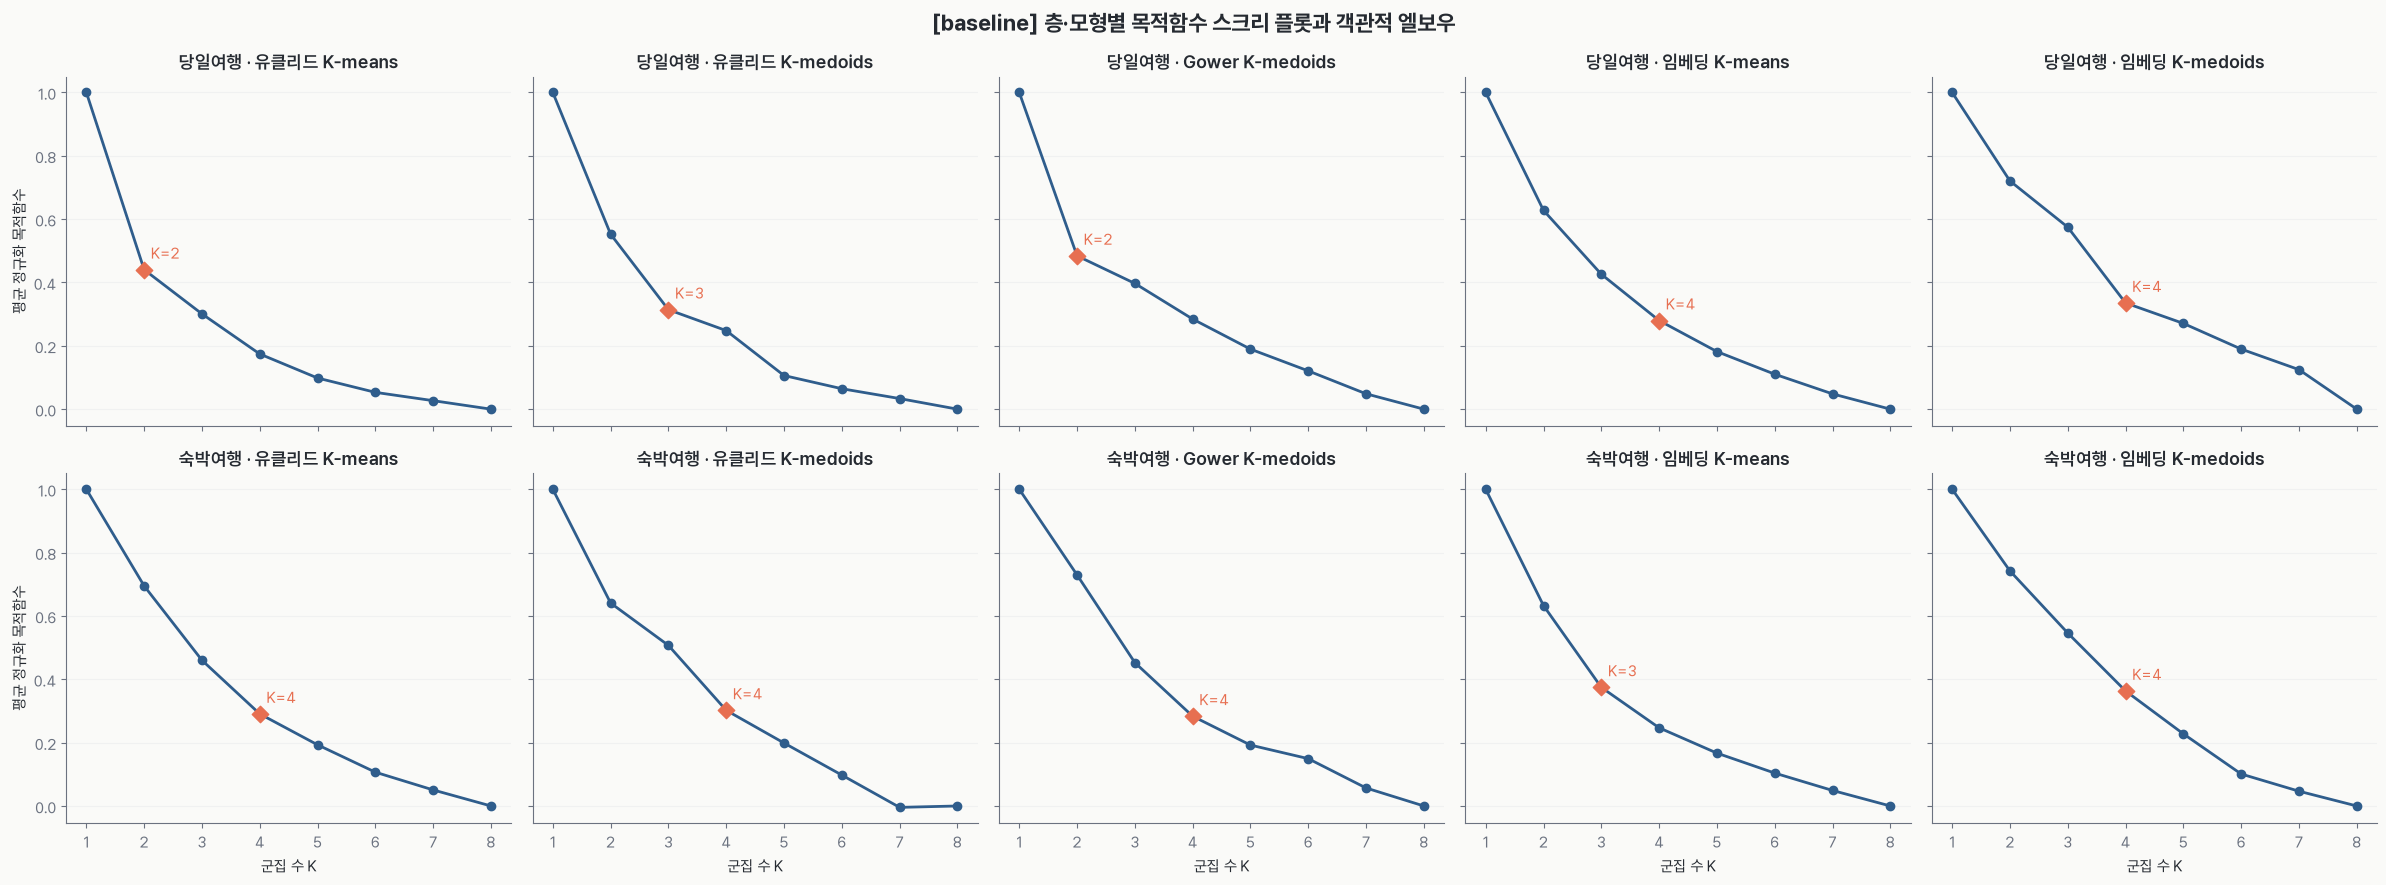

In [13]:
baseline_k = select_optimal_k("baseline", baseline_fit)

[baseline] 모형 비교와 최종 선택


,층,모형,K,전체 자체 실루엣,전체 공통 Gower 실루엣,안정성 ARI,최소 군집 비중,대표 seed,유효 seed 수,기본 조건 통과,Pareto 후보
0,당일여행,Gower K-medoids,2,0.133,0.133,0.703,0.443,20260720,5,True,True
1,당일여행,유클리드 K-means,2,0.483,0.096,1.000,0.119,20260720,5,True,True
2,당일여행,유클리드 K-medoids,3,0.202,0.100,0.552,0.104,101,5,True,True
3,당일여행,임베딩 K-means,4,0.351,0.124,0.998,0.004,20260720,5,False,False
4,당일여행,임베딩 K-medoids,4,0.128,0.093,0.397,0.085,2025,5,False,False
5,숙박여행,Gower K-medoids,4,0.145,0.145,0.322,0.126,2025,5,False,False
6,숙박여행,유클리드 K-means,4,0.113,0.156,1.000,0.095,20260720,5,True,True
7,숙박여행,유클리드 K-medoids,4,0.081,0.107,0.415,0.133,2025,5,False,False
8,숙박여행,임베딩 K-means,3,0.300,0.098,0.999,0.115,20260720,5,True,True
9,숙박여행,임베딩 K-medoids,4,0.121,0.085,0.326,0.119,43,5,False,False


,층,선택 상태,모형,K,대표 seed
0,당일여행,선택,유클리드 K-means,2,20260720
1,숙박여행,선택,임베딩 K-means,3,20260720


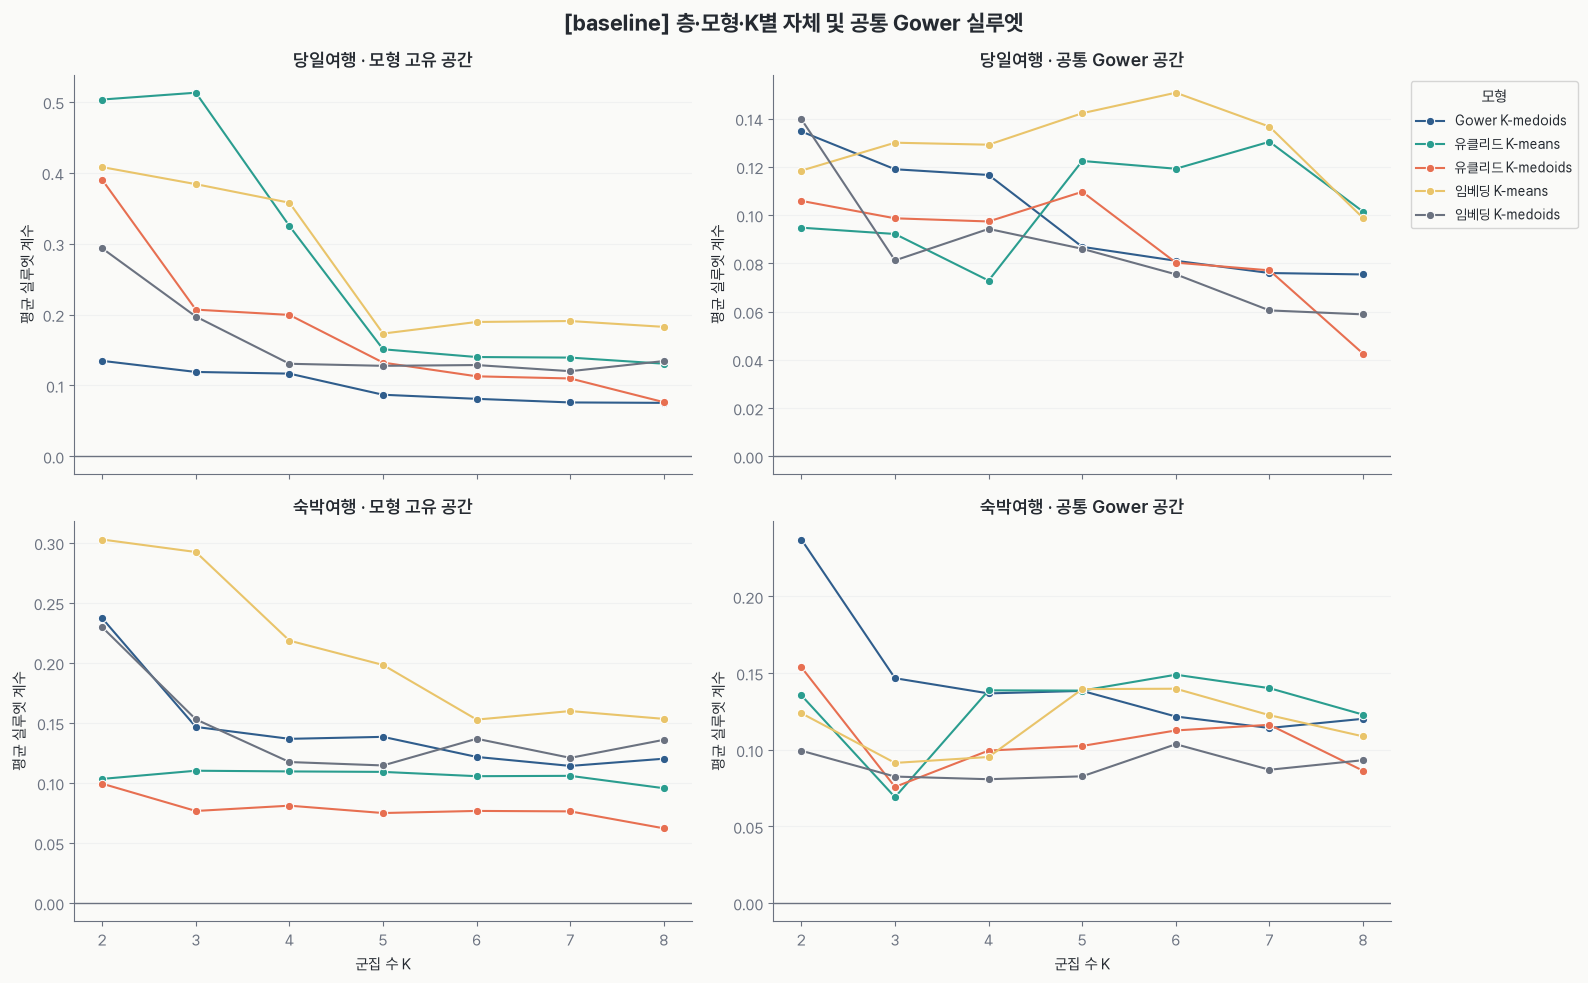

In [14]:
baseline_model = select_optimal_model("baseline", baseline_fit, baseline_k)

[baseline] 최종 군집 규모와 외부 프로파일


,층,군집,비가중 N,가중 여행 사례 수,층 내 가중 구성비
0,당일여행,당일여행 C2,5033,4.952222e+07,0.881
1,당일여행,당일여행 C1,677,6.700951e+06,0.119
2,숙박여행,숙박여행 C1,1277,1.287971e+07,0.183
3,숙박여행,숙박여행 C2,812,5.529295e+06,0.079
4,숙박여행,숙박여행 C3,4991,5.190968e+07,0.738


,층,군집,변수,가중 평균·비율,층 평균·비율,lift
55,당일여행,당일여행 C1,share_activity,0.282,0.045,6.301
19,당일여행,당일여행 C1,activity_experience,0.286,0.059,4.886
59,당일여행,당일여행 C1,activity_spend,1.000,0.253,3.952
21,당일여행,당일여행 C1,activity_leisure,0.106,0.036,2.949
9,당일여행,당일여행 C1,information_online,0.221,0.126,1.761
33,당일여행,당일여행 C1,with_child,0.218,0.125,1.745
17,당일여행,당일여행 C1,activity_culture,0.269,0.164,1.643
44,당일여행,당일여행 C2,multi_region,0.021,0.019,1.079
56,당일여행,당일여행 C2,share_shopping,0.039,0.037,1.068
6,당일여행,당일여행 C2,information_none,0.227,0.215,1.056


,층,군집,지표,가중 평균,비가중 N,결측 N,가중 분모
0,당일여행,당일여행 C2,전반적 만족도(1~5),4.136,5033,0,4.952222e+07
1,당일여행,당일여행 C2,재방문 의향(1~5),4.028,5033,0,4.952222e+07
2,당일여행,당일여행 C2,추천 의향(1~5),3.914,5033,0,4.952222e+07
3,당일여행,당일여행 C1,전반적 만족도(1~5),4.202,677,0,6.700951e+06
4,당일여행,당일여행 C1,재방문 의향(1~5),4.115,677,0,6.700951e+06
5,당일여행,당일여행 C1,추천 의향(1~5),4.018,677,0,6.700951e+06
6,숙박여행,숙박여행 C1,전반적 만족도(1~5),4.253,1277,0,1.287971e+07
7,숙박여행,숙박여행 C1,재방문 의향(1~5),4.112,1277,0,1.287971e+07
8,숙박여행,숙박여행 C1,추천 의향(1~5),3.985,1277,0,1.287971e+07
9,숙박여행,숙박여행 C2,전반적 만족도(1~5),4.245,812,0,5.529295e+06


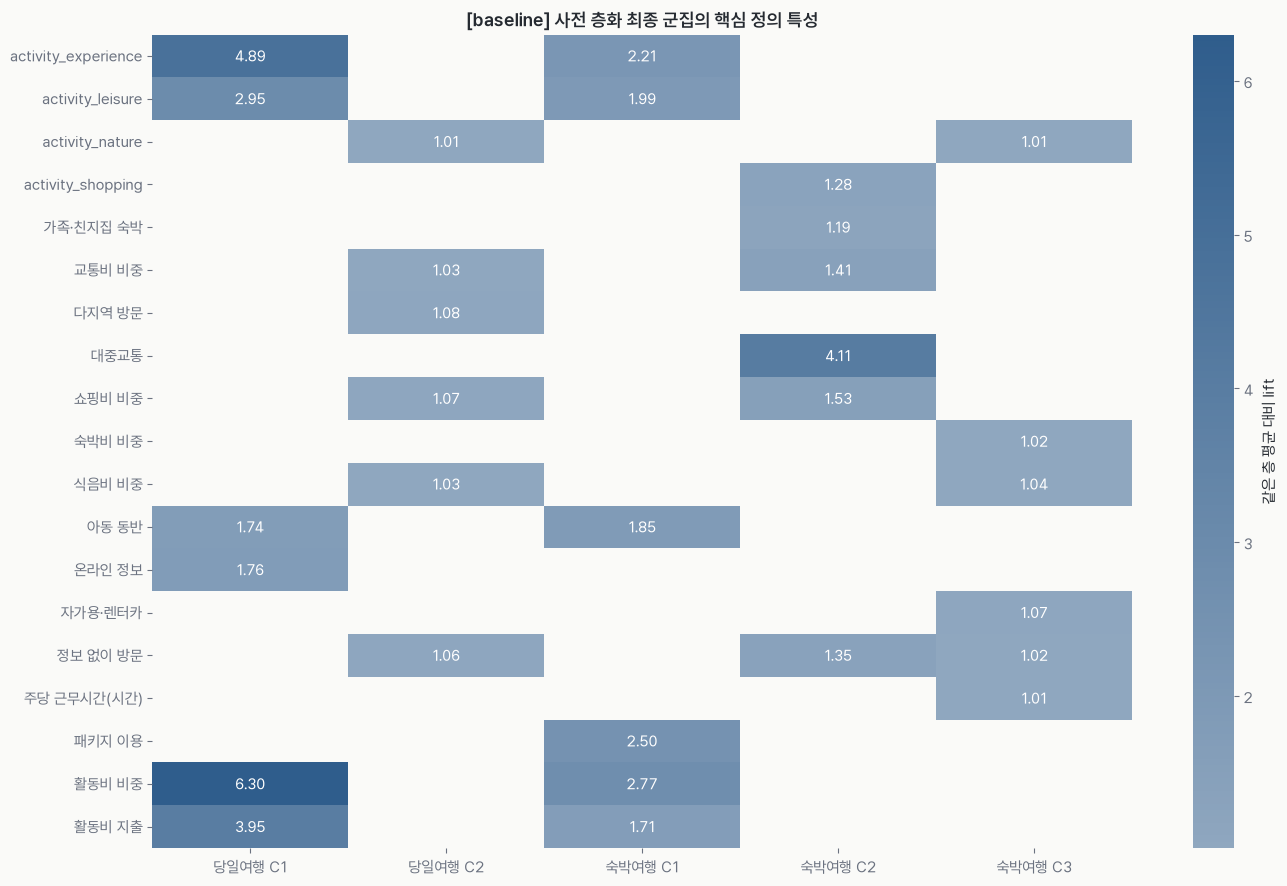

[baseline] 군집 라벨링 데이터 저장: C:\Users\ilove\Desktop\tourism_poster\outputs\260720_연고관광_사전층화_클러스터링_3개년_old\tables\baseline_stratified_cluster_labeled_data.csv


In [19]:
baseline_clustered = identify_defining_features(
    "baseline", FEATURE_DOMAINS_BASELINE, CATEGORICAL_FEATURES_BASELINE,
    baseline_fit, baseline_model,
)

[baseline_mixed_embedding] 최종 군집 규모와 외부 프로파일


,층,군집,비가중 N,가중 여행 사례 수,층 내 가중 구성비
0,당일여행,당일여행 C2,5033,4.952222e+07,0.881
1,당일여행,당일여행 C1,677,6.700951e+06,0.119
2,숙박여행,숙박여행 C1,1277,1.287971e+07,0.183
3,숙박여행,숙박여행 C2,812,5.529295e+06,0.079
4,숙박여행,숙박여행 C3,4991,5.190968e+07,0.738


,층,군집,변수,가중 평균·비율,층 평균·비율,lift
55,당일여행,당일여행 C1,share_activity,0.282,0.045,6.301
19,당일여행,당일여행 C1,activity_experience,0.286,0.059,4.886
59,당일여행,당일여행 C1,activity_spend,1.000,0.253,3.952
21,당일여행,당일여행 C1,activity_leisure,0.106,0.036,2.949
9,당일여행,당일여행 C1,information_online,0.221,0.126,1.761
44,당일여행,당일여행 C2,multi_region,0.021,0.019,1.079
56,당일여행,당일여행 C2,share_shopping,0.039,0.037,1.068
6,당일여행,당일여행 C2,information_none,0.227,0.215,1.056
52,당일여행,당일여행 C2,share_transport,0.279,0.271,1.030
50,당일여행,당일여행 C2,share_food,0.647,0.628,1.030


,층,군집,지표,가중 평균,비가중 N,결측 N,가중 분모
0,당일여행,당일여행 C2,전반적 만족도(1~5),4.136,5033,0,4.952222e+07
1,당일여행,당일여행 C2,재방문 의향(1~5),4.028,5033,0,4.952222e+07
2,당일여행,당일여행 C2,추천 의향(1~5),3.914,5033,0,4.952222e+07
3,당일여행,당일여행 C1,전반적 만족도(1~5),4.202,677,0,6.700951e+06
4,당일여행,당일여행 C1,재방문 의향(1~5),4.115,677,0,6.700951e+06
5,당일여행,당일여행 C1,추천 의향(1~5),4.018,677,0,6.700951e+06
6,숙박여행,숙박여행 C1,전반적 만족도(1~5),4.253,1277,0,1.287971e+07
7,숙박여행,숙박여행 C1,재방문 의향(1~5),4.112,1277,0,1.287971e+07
8,숙박여행,숙박여행 C1,추천 의향(1~5),3.985,1277,0,1.287971e+07
9,숙박여행,숙박여행 C2,전반적 만족도(1~5),4.245,812,0,5.529295e+06


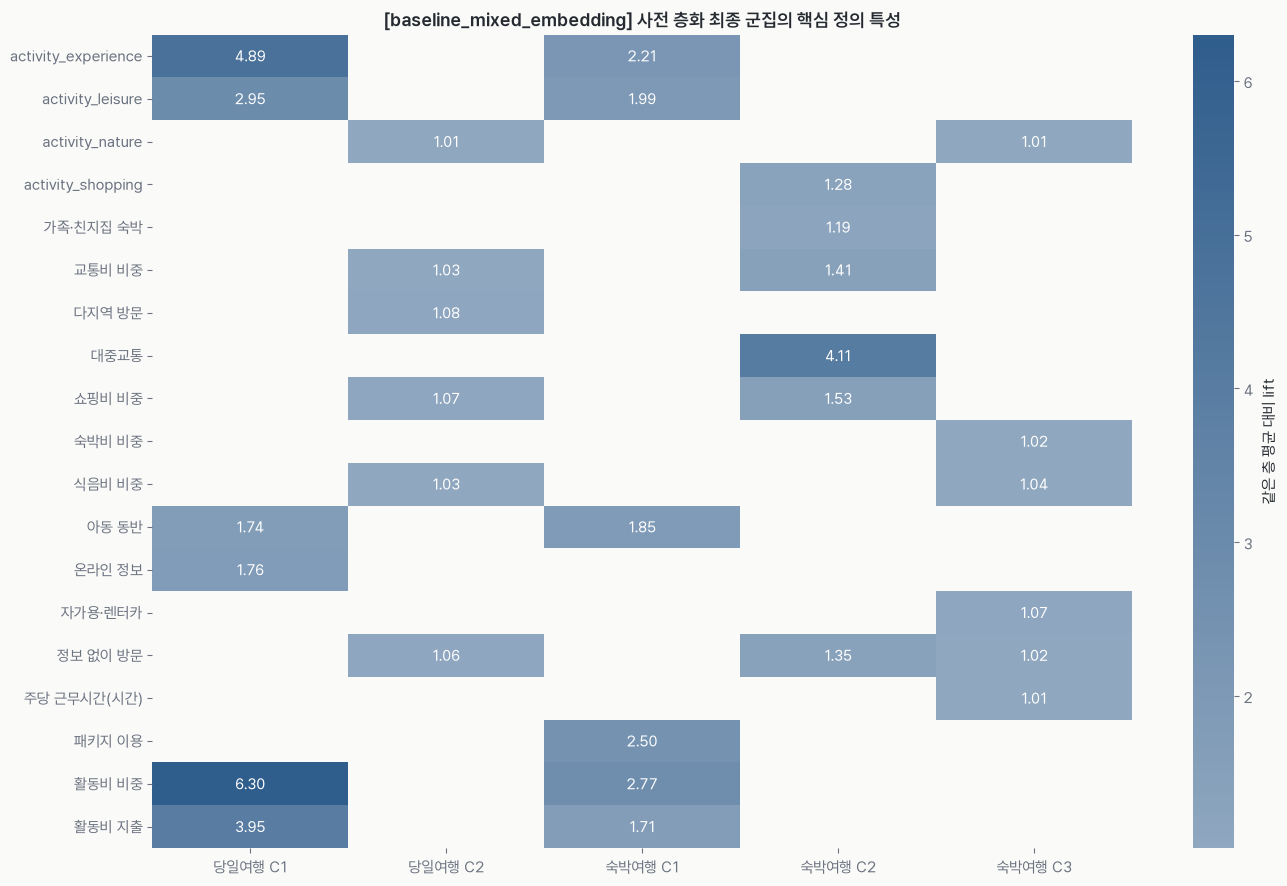

[baseline_mixed_embedding] 군집 라벨링 데이터 저장: C:\Users\ilove\Desktop\tourism_poster\outputs\260720_연고관광_사전층화_클러스터링_3개년_old\tables\baseline_mixed_embedding_stratified_cluster_labeled_data.csv


In [16]:
embedding_row = (
    baseline_model["model_comparison"]
    .loc[lambda df: df["층"].eq("숙박여행") & df["모형"].eq("임베딩 K-means")]
    .assign(**{"선택 상태": "선택"})
    [["층", "선택 상태", "모형", "K", "대표 seed"]]
)

mixed_selection_table = pd.concat([
    baseline_model["selection_table"].loc[lambda df: df["층"].ne("숙박여행")],
    embedding_row,
], ignore_index=True)

mixed_model_context = {"selection_table": mixed_selection_table}

mixed_clustered = identify_defining_features(
    "baseline_mixed_embedding", FEATURE_DOMAINS_BASELINE, CATEGORICAL_FEATURES_BASELINE,
    baseline_fit, mixed_model_context,
)


## 9. 2단계 실행: full(소비·준비 세부 확장)

변수 수가 baseline보다 많아 특히 군집 적합 셀(9.1)이 Gower 거리·
오토인코더 학습 때문에 더 오래 걸릴 수 있다. 첫 실행 시 시간이 과도하면
사용자에게 보고한다.

In [ ]:
# full_fit = fit_stratified_clustering(
#     "full", FEATURE_DOMAINS_FULL, CATEGORICAL_FEATURES_FULL
# )

In [ ]:
# full_k = select_optimal_k("full", full_fit)

In [ ]:
# full_model = select_optimal_model("full", full_fit, full_k)

In [ ]:
# full_clustered = identify_defining_features(
#     "full", FEATURE_DOMAINS_FULL, CATEGORICAL_FEATURES_FULL,
#     full_fit, full_model,
# )

## 10. 핵심 결과와 한계

- 엘보우는 모형의 목적함수 감소가 완만해지는 지점을 재현 가능한
  규칙으로 찾지만, 유일한 참 군집 수를 증명하지 않는다.
- 자체 실루엣은 서로 다른 공간의 절댓값을 직접 비교하기 어렵다. Pareto
  판정에 함께 쓰되 최종 동률 해소는 동일 Gower 거리에서 계산한 공통
  실루엣을 우선한다.
- 소비는 두 단계 모두 군집 정의에 사용했으므로 군집별 소비 차이를
  외부 검증으로 표현하지 않는다. 만족도·재방문·추천 의향만 입력 외
  프로파일이다.
- `WT_DOM` 가중 합은 연간 고유 방문자 수가 아니라 가중 여행 사례 수다.
- 안정성·최소 크기 조건(안정성 ARI 0.5)을 통과하는 후보가 없으면
  해당 층에 하위 군집이 없다고 증명한 것이 아니라, 현재 변수·모형에서
  안정적인 근거가 부족한 것으로 해석한다.
- baseline 대비 full은 소비·준비 세부항목이 늘어난 만큼 Gower 거리의
  희소·결측 패턴에 더 민감할 수 있어, 두 단계의 최종 K와 안정성 ARI를
  함께 비교해 변수 확장이 해석을 얼마나 바꾸는지 판단한다.

In [ ]:
print("[3개년 사전 층화 군집분석 최종 요약]")
print(f"- CASE 2 분석 여행: {len(analysis_data):,}건")
for phase_name, model_context in [
    ("baseline", baseline_model), ("full", full_model),
]:
    selection_table = model_context["selection_table"]
    model_comparison = model_context["model_comparison"]
    print(f"[{phase_name}]")
    for _, row in selection_table.iterrows():
        if row["선택 상태"] == "선택":
            metric = model_comparison.loc[
                model_comparison["층"].eq(row["층"])
                & model_comparison["모형"].eq(row["모형"])
            ].iloc[0]
            print(
                f"  - {row['층']}: {row['모형']}, K={int(row['K'])}, "
                f"자체={metric['전체 자체 실루엣']:.3f}, "
                f"Gower={metric['전체 공통 Gower 실루엣']:.3f}, "
                f"ARI={metric['안정성 ARI']:.3f}"
            )
        else:
            print(f"  - {row['층']}: {row['선택 상태']}")
print("- 결과표와 그림은 {baseline,full}_stratified_cluster_* 이름으로 저장했습니다.")